# Análisis descriptivo del BIRD-SQL completo con esquemas

Este notebook analiza las anotaciones públicas completas de entrenamiento de BIRD-SQL, las enlaza con los esquemas oficiales y prepara particiones de entrenamiento, validación y prueba interna para un experimento reproducible. La unidad de agrupacion para la prueba interna es la base de datos (`db_id`), con el fin de evitar que un mismo esquema aparezca a la vez en entrenamiento y prueba.


## 1. Fuente, licencia y particiones

Los cuatro JSON se descargan de un mirror comunitario de los archivos originales en [Hugging Face](https://huggingface.co/datasets/Deema/BIRD-SQL). La fuente canonica del benchmark es el [sitio oficial BIRD](https://bird-bench.github.io/). El dev usado aqui es la particion publica incluida junto al train original.

La licencia del benchmark es **CC BY-SA 4.0**. Deben darse los creditos correspondientes y mantenerse la misma licencia en redistribuciones derivadas.

BIRD publica el train y el dev con anotaciones. El test oficial tiene etiquetas ocultas y se evalua mediante el canal oficial del benchmark. Para que este proyecto cuente con tres particiones etiquetadas, se toma el train completo de 9.428 ejemplos y se separa un **test interno por bases de datos**: aproximadamente el 20 % de los `db_id` del train queda reservado para prueba, mientras el resto se usa para entrenamiento. El dev publico se conserva como validacion. Este test interno es una particion experimental, no el test oculto oficial.

## 2. Carga de anotaciones y esquemas

In [81]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from pathlib import Path
from huggingface_hub import hf_hub_download
from wordcloud import WordCloud

REPO_ID = "Deema/BIRD-SQL"
def download_json(filename):
    path = hf_hub_download(repo_id=REPO_ID, filename=filename, repo_type="dataset")
    with open(path, encoding="utf-8") as f:
        return json.load(f)

train_full = pd.DataFrame(download_json("train.json"))
dev_public = pd.DataFrame(download_json("dev.json"))
train_schemas_raw = download_json("train_tables.json")
dev_schemas_raw = download_json("dev_tables.json")

train_full["source_split"] = "train_original"
dev_public["source_split"] = "dev_oficial"

print("Train original completo:", train_full.shape)
print("Dev publico:", dev_public.shape)
print("Campos train:", train_full.columns.tolist())
print("Campos dev:", dev_public.columns.tolist())
print("Esquemas train/dev:", len(train_schemas_raw), len(dev_schemas_raw))


Train original completo: (9428, 5)
Dev publico: (1534, 7)
Campos train: ['db_id', 'question', 'evidence', 'SQL', 'source_split']
Campos dev: ['question_id', 'db_id', 'question', 'evidence', 'SQL', 'difficulty', 'source_split']
Esquemas train/dev: 69 11


### 2.1. Ejemplos reales de `evidence` y cómo interpretarlos

En BIRD, `evidence` es una anotación que aporta información auxiliar para interpretar la pregunta: puede aclarar el significado de un código, identificar una columna o describir un cálculo. Se utiliza junto con la pregunta y el esquema para construir el SQL.

Los tres ejemplos siguientes proceden del archivo `train.json` de [Deema/BIRD-SQL](https://huggingface.co/datasets/Deema/BIRD-SQL), que se carga arriba como `train_full`. Se seleccionan por base y pregunta para que las explicaciones siempre correspondan a los mismos casos. Las preguntas, evidencias y consultas se muestran en su idioma original; las explicaciones están escritas en español. Esta sección usa el entrenamiento original antes de crear las particiones experimentales.


In [82]:
from IPython.display import Markdown, display


def mostrar_evidence_real(datos, db_id, pregunta, titulo):
    # La selección exacta mantiene alineados los ejemplos con su explicación.
    coincidencias = [
        fila for fila in datos
        if fila["db_id"] == db_id and fila["question"] == pregunta
    ]
    if len(coincidencias) != 1:
        raise ValueError(
            f"Se esperaba un ejemplo único para {db_id}, pero hay {len(coincidencias)}."
        )
    ejemplo = coincidencias[0]
    display(Markdown(
        f"#### {titulo}\n\n"
        f"**Base:** `{ejemplo['db_id']}`  |  **Fuente:** train original\n\n"
        f"**Pregunta original:** {ejemplo['question']}\n\n"
        f"**Evidence original:**\n\n> {ejemplo['evidence']}\n\n"
        f"**SQL de referencia:**\n\n```sql\n{ejemplo['SQL']}\n```"
    ))


registros_evidence = train_full.to_dict(orient="records")

mostrar_evidence_real(
    registros_evidence,
    "social_media",
    "How many tweets are in English?",
    "Ejemplo 1: interpretar un código",
)


#### Ejemplo 1: interpretar un código

**Base:** `social_media`  |  **Fuente:** train original

**Pregunta original:** How many tweets are in English?

**Evidence original:**

> english is the language and refers to Lang = 'en'

**SQL de referencia:**

```sql
SELECT COUNT(TweetID) AS tweet_number FROM twitter WHERE Lang = 'en'
```

**Explicación del ejemplo 1.** La pregunta pide cuántos tuits están en inglés. La evidencia dice que «inglés» corresponde a `Lang = 'en'`: identifica tanto la columna de idioma (`Lang`) como el código almacenado para ese idioma (`en`).

La consulta busca en la tabla `twitter`, conserva las filas con `WHERE Lang = 'en'` y cuenta sus identificadores mediante `COUNT(TweetID)`. El resultado recibe el nombre `tweet_number`. La evidencia ayuda a elegir el valor correcto del filtro; conocer únicamente el nombre de la columna no revela necesariamente qué código utiliza la base.


In [83]:
mostrar_evidence_real(
    registros_evidence,
    "cs_semester",
    "Which course is more difficult, Intro to BlockChain or Computer Network?",
    "Ejemplo 2: interpretar una medida",
)


#### Ejemplo 2: interpretar una medida

**Base:** `cs_semester`  |  **Fuente:** train original

**Pregunta original:** Which course is more difficult, Intro to BlockChain or Computer Network?

**Evidence original:**

> diff refers to difficulty; diff is higher means the course is more difficult;

**SQL de referencia:**

```sql
SELECT name FROM course WHERE name = 'Intro to BlockChain' OR name = 'Computer Network' ORDER BY diff DESC LIMIT 1
```

**Explicación del ejemplo 2.** La pregunta compara la dificultad de dos cursos: *Intro to BlockChain* y *Computer Network*. La evidencia aclara que la columna `diff` representa la dificultad y que un valor mayor significa un curso más difícil.

La consulta selecciona esos dos cursos de la tabla `course` con `WHERE ... OR ...`, los ordena de mayor a menor dificultad mediante `ORDER BY diff DESC` y devuelve el primero con `LIMIT 1`. La evidencia permite decidir qué columna comparar y en qué dirección ordenar sus valores.


In [84]:
mostrar_evidence_real(
    registros_evidence,
    "book_publishing_company",
    "Which date has the most ordered quantity? What is the total order quantity on that day?",
    "Ejemplo 3: definir una suma y una comparación",
)


#### Ejemplo 3: definir una suma y una comparación

**Base:** `book_publishing_company`  |  **Fuente:** train original

**Pregunta original:** Which date has the most ordered quantity? What is the total order quantity on that day?

**Evidence original:**

> total quantity refers to qty; most ordered quantity refers to order with the highest quantity where MAX(sum(qty))

**SQL de referencia:**

```sql
SELECT ord_date, SUM(qty) FROM sales GROUP BY ord_date ORDER BY SUM(qty) DESC LIMIT 1
```

**Explicación del ejemplo 3.** La pregunta pide la fecha con mayor cantidad total pedida y cuál fue esa cantidad. La evidencia relaciona «cantidad» con la columna `qty` y señala que interesa el mayor total, expresado en la anotación como `MAX(sum(qty))`.

La consulta agrupa las filas de `sales` por fecha mediante `GROUP BY ord_date` y calcula `SUM(qty)` para cada fecha. Después ordena esos totales de mayor a menor con `ORDER BY SUM(qty) DESC` y conserva la primera fila con `LIMIT 1`. Así obtiene la fecha y su total. La notación de la evidencia describe la idea del cálculo; el SQL de referencia la implementa mediante agrupación y ordenamiento, sin copiar literalmente `MAX(sum(qty))`.

Este caso muestra por qué importa la aclaración: buscar la fila individual con mayor `qty` podría producir una respuesta diferente a sumar todas las filas de cada fecha.


## 3. Crear entrenamiento, validación y prueba interna

Se preserva `dev` como validación y se reserva una fracción de las bases completas de train para el test interno. De esta manera no se repiten esquemas entre entrenamiento y prueba. La semilla hace reproducible la asignación de `db_id`.


In [85]:
# Reserva 20% de las bases de train para test interno, no 20% de filas al azar.
TEST_DB_FRACTION = 0.20
RANDOM_SEED = 42
train_db_ids = np.array(sorted(train_full["db_id"].unique()))
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(train_db_ids)
n_test_dbs = max(1, int(np.ceil(len(train_db_ids) * TEST_DB_FRACTION)))
test_db_ids = set(train_db_ids[:n_test_dbs])

train_df = train_full.loc[~train_full["db_id"].isin(test_db_ids)].copy()
test_internal_df = train_full.loc[train_full["db_id"].isin(test_db_ids)].copy()
validation_df = dev_public.copy()

train_db_set = set(train_df["db_id"])
test_db_set = set(test_internal_df["db_id"])
validation_db_set = set(validation_df["db_id"])
assert train_db_set.isdisjoint(test_db_set)
assert train_db_set.isdisjoint(validation_db_set)
assert test_db_set.isdisjoint(validation_db_set)
assert len(train_df) + len(test_internal_df) == len(train_full)

train_df["split"] = "train"
test_internal_df["split"] = "test_interno"
validation_df["split"] = "validation"
df = pd.concat([train_df, validation_df, test_internal_df], ignore_index=True)

print("Filas por particion:")
display(df["split"].value_counts().to_frame("ejemplos"))
print("Bases por particion:", {"train":len(train_db_set), "validation":len(validation_db_set), "test_interno":len(test_db_set)})
print("Solapamientos de db_id:", len(train_db_set & validation_db_set), len(train_db_set & test_db_set), len(validation_db_set & test_db_set))


Filas por particion:


,ejemplos
split,
train,7996
validation,1534
test_interno,1432


Bases por particion: {'train': 55, 'validation': 11, 'test_interno': 14}
Solapamientos de db_id: 0 0 0


## 4. Enlazar metadatos de esquema

BIRD entrega los esquemas como registros separados. `train_tables.json` y `dev_tables.json` contienen tablas, columnas, tipos, claves primarias y claves foraneas. Se enlazan por `db_id`; luego se calculan conteos estructurales para cada ejemplo. Los objetos completos permanecen disponibles en el diccionario `schemas`.


In [86]:
all_schema_records = train_schemas_raw + dev_schemas_raw
schemas = {schema["db_id"]: schema for schema in all_schema_records}
if len(schemas) != len(all_schema_records):
    raise ValueError("Hay db_id duplicados al combinar esquemas train y dev")
missing_ids = sorted(set(df["db_id"]) - set(schemas))
if missing_ids:
    raise ValueError(f"Faltan esquemas para estos db_id: {missing_ids}")


def indices_clave_primaria(values):
    """Obtiene las columnas PK, incluyendo los grupos de claves compuestas."""
    indices = set()
    for value in values:
        if isinstance(value, (list, tuple)):
            indices.update(indices_clave_primaria(value))
        else:
            indices.add(int(value))
    return indices


def summarize_schema(schema):
    columns = schema.get("column_names_original")
    if columns is None:
        columns = schema["column_names"]
    tables = schema.get("table_names_original")
    if tables is None:
        tables = schema["table_names"]
    user_indices = {
        i for i, (table_id, name) in enumerate(columns)
        if table_id >= 0 and name != "*"
    }
    pk_indices = indices_clave_primaria(schema.get("primary_keys", []))
    if not pk_indices.issubset(user_indices):
        raise ValueError(f"Índices PK no válidos en {schema['db_id']}")
    fk_indices, fk_tables = set(), set()
    foreign_keys = schema.get("foreign_keys", [])
    for source, target in foreign_keys:
        endpoints = {int(source), int(target)}
        if not endpoints.issubset(user_indices):
            raise ValueError(f"Índices FK no válidos en {schema['db_id']}")
        fk_indices.update(endpoints)
        fk_tables.update(columns[i][0] for i in endpoints)

    num_tables, num_columns = len(tables), len(user_indices)
    key_columns = pk_indices | fk_indices
    type_counts = Counter(
        schema["column_types"][i]
        for i in user_indices if i < len(schema["column_types"])
    )
    return {
        "db_id": schema["db_id"],
        "num_tables": num_tables,
        "num_columns": num_columns,
        "num_primary_keys": len(pk_indices),
        "num_foreign_keys": len(foreign_keys),
        "tables_with_foreign_keys": len(fk_tables),
        "pct_tables_with_foreign_keys": 100 * len(fk_tables) / num_tables if num_tables else 0,
        "key_columns": len(key_columns),
        "pct_columns_marked_as_keys": 100 * len(key_columns) / num_columns if num_columns else 0,
        "column_type_counts": dict(type_counts),
    }


# Una fila por base: los esquemas no se repiten por cada pregunta.
schema_summary = pd.DataFrame(
    summarize_schema(schemas[db_id]) for db_id in sorted(df["db_id"].unique())
)
summary_by_db = schema_summary.set_index("db_id")
schema_metric_columns = [
    "num_tables", "num_columns", "num_primary_keys", "num_foreign_keys",
    "tables_with_foreign_keys", "pct_tables_with_foreign_keys",
    "key_columns", "pct_columns_marked_as_keys",
]
for feature in schema_metric_columns:
    df[feature] = df["db_id"].map(summary_by_db[feature])

print("Ejemplos con esquema enlazado:", df["num_tables"].notna().sum(), "/", len(df))
print("Bases con esquema:", len(schema_summary))
display(schema_summary[schema_metric_columns].describe().round(2))


Ejemplos con esquema enlazado: 10962 / 10962
Bases con esquema: 80


,num_tables,num_columns,num_primary_keys,num_foreign_keys,tables_with_foreign_keys,pct_tables_with_foreign_keys,key_columns,pct_columns_marked_as_keys
count,80.00,80.00,80.00,80.00,80.00,80.00,80.00,80.00
mean,7.46,54.21,9.02,6.58,5.76,80.24,13.41,28.96
std,8.33,64.17,12.59,9.24,6.96,36.96,16.16,17.47
min,2.00,6.00,0.00,0.00,0.00,0.00,1.00,2.94
25%,3.75,20.75,4.00,2.00,3.00,84.62,5.00,17.30
50%,5.00,38.50,6.00,4.00,4.50,100.00,9.00,25.03
75%,8.00,61.75,10.00,8.00,7.25,100.00,16.00,37.50
max,65.00,455.00,91.00,61.00,56.00,100.00,114.00,83.33


## 5. Estructura y variables

La observacion principal es una pregunta asociada a SQL, evidencia y base de datos. La columna `split` distingue las particiones usadas en el experimento; las medidas estructurales se derivan de los metadatos de esquema.

| Variable | Tipo / formato | Significado |
|---|---|---|
| `question` | Texto | Pregunta en inglés escrita en lenguaje natural. |
| `evidence` | Texto; puede estar vacio | Conocimiento auxiliar anotado para aclarar valores, conceptos o condiciones. |
| `SQL` | Texto | Consulta SQL de referencia. |
| `db_id` | Texto | Identificador de la base objetivo y clave para unir con su esquema. |
| `source_split` | Texto | Fuente original: train sin filtrar o dev oficial. |
| `split` | Texto | Particion experimental: `train`, `validation` o `test_interno`. |
| `table_names` / `table_names_original` | Listas de textos en `schemas` | Nombres de tablas normalizados y originales. |
| `column_names` / `column_names_original` | Listas `[indice_tabla, nombre]` | Nombres de columnas y tabla a la que pertenecen. |
| `column_types` | Lista de textos en `schemas` | Tipo de cada columna. |
| `primary_keys` | Lista de indices | Columnas que forman claves primarias. |
| `foreign_keys` | Pares de indices | Relaciones de clave foránea entre columnas. |
| `num_tables`, `num_columns`, `num_primary_keys`, `num_foreign_keys` | Enteros derivados | Conteos de tablas, columnas y claves por base. |


In [87]:
display(df.dtypes.to_frame("tipo"))
missing = pd.DataFrame({"faltantes":df.isna().sum(), "porcentaje":(df.isna().mean()*100).round(2)})
display(missing)
summary = pd.DataFrame({
    "metrica":["Ejemplos publicos analizados","Train original completo","Train tras reserva de test","Validacion dev","Test interno","Bases train original","Bases dev"],
    "valor":[len(df),len(train_full),len(train_df),len(validation_df),len(test_internal_df),train_full["db_id"].nunique(),dev_public["db_id"].nunique()]
})
display(summary)


,tipo
db_id,str
question,str
evidence,str
SQL,str
source_split,str
split,str
question_id,float64
difficulty,str
num_tables,int64
num_columns,int64


,faltantes,porcentaje
db_id,0,0.00
question,0,0.00
evidence,0,0.00
SQL,0,0.00
source_split,0,0.00
split,0,0.00
question_id,9428,86.01
difficulty,9428,86.01
num_tables,0,0.00
num_columns,0,0.00


,metrica,valor
0,Ejemplos publicos analizados,10962
1,Train original completo,9428
2,Train tras reserva de test,7996
3,Validacion dev,1534
4,Test interno,1432
5,Bases train original,69
6,Bases dev,11


### 5.1. Preguntas y consultas SQL únicas

Se cuentan textos distintos con `nunique()`, sobre entrenamiento, validación y prueba interna combinados. Una pregunta puede repetirse para bases diferentes; el conteo global de preguntas la considera una sola vez. Las diferencias de mayúsculas, espacios o puntuación cuentan como textos distintos.

Las consultas SQL también se comparan literalmente, sin comprobar equivalencia semántica. Varias preguntas pueden compartir el mismo SQL y una misma cadena SQL puede aparecer en bases diferentes. Por eso, la tabla incorpora las combinaciones con `db_id`: permite distinguir repetición de texto de repetición del ejemplo asociado a una base. Los valores nulos no se cuentan en `nunique()`. La diferencia entre filas y textos únicos cuenta apariciones adicionales, no necesariamente el número de textos que se repiten.


In [88]:
# Comparación literal sobre todos los ejemplos públicos cargados.
unique_summary = pd.DataFrame({
    "Métrica": [
        "Bases de datos distintas", "Preguntas únicas", "Consultas SQL únicas",
        "Combinaciones únicas de base y pregunta",
        "Combinaciones únicas de base, pregunta y SQL",
    ],
    "Valor": [
        df["db_id"].nunique(), df["question"].nunique(), df["SQL"].nunique(),
        len(df.drop_duplicates(["db_id", "question"])),
        len(df.drop_duplicates(["db_id", "question", "SQL"])),
    ],
})
display(unique_summary)


,Métrica,Valor
0,Bases de datos distintas,80
1,Preguntas únicas,10949
2,Consultas SQL únicas,10842
3,Combinaciones únicas de base y pregunta,10951
4,"Combinaciones únicas de base, pregunta y SQL",10958


## 6. Variables derivadas y complejidad SQL

In [89]:
df["question_words"] = df["question"].fillna("").str.split().str.len()
df["sql_words"] = df["SQL"].fillna("").str.split().str.len()
df["evidence_words"] = df["evidence"].fillna("").str.split().str.len()
df["question_chars"] = df["question"].fillna("").str.len()
df["sql_chars"] = df["SQL"].fillna("").str.len()
display(df[["question_words","sql_words","evidence_words","question_chars","sql_chars"]].describe().round(2))

def sql_features(sql):
    s=str(sql).upper()
    return {
        "JOIN":bool(re.search(r"\bJOIN\b",s)),
        "GROUP BY":bool(re.search(r"\bGROUP\s+BY\b",s)),
        "ORDER BY":bool(re.search(r"\bORDER\s+BY\b",s)),
        "HAVING":bool(re.search(r"\bHAVING\b",s)),
        "DISTINCT":bool(re.search(r"\bDISTINCT\b",s)),
        "LIMIT":bool(re.search(r"\bLIMIT\b",s)),
        "UNION":bool(re.search(r"\bUNION\b",s)),
        "INTERSECT":bool(re.search(r"\bINTERSECT\b",s)),
        "EXCEPT":bool(re.search(r"\bEXCEPT\b",s)),
        "AGREGACION":bool(re.search(r"\b(COUNT|SUM|AVG|MIN|MAX)\s*\(",s)),
        "SUBCONSULTA":len(re.findall(r"\bSELECT\b",s))>1,
    }
features = df["SQL"].apply(sql_features).apply(pd.Series)
construct_counts = features.sum().sort_values(ascending=False)
display(construct_counts.to_frame("numero_de_consultas"))


,question_words,sql_words,evidence_words,question_chars,sql_chars
count,10962.00,10962.00,10962.00,10962.00,10962.00
mean,14.12,25.75,14.57,80.22,168.89
std,5.34,11.71,9.62,30.55,77.17
min,4.00,4.00,0.00,23.00,23.00
25%,10.00,19.00,8.00,58.00,123.00
50%,13.00,24.00,13.00,75.00,160.00
75%,17.00,32.00,19.00,96.00,206.00
max,59.00,178.00,101.00,325.00,1446.00


,numero_de_consultas
JOIN,8352
AGREGACION,5157
LIMIT,2097
ORDER BY,2027
DISTINCT,1323
GROUP BY,1129
SUBCONSULTA,862
HAVING,160
UNION,31
EXCEPT,2


## 7. Graficas: particiones, dominios y construcciones SQL

Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\01_particiones_bird.png


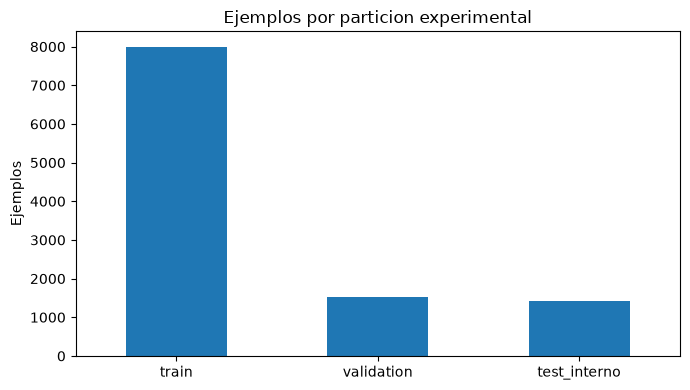

Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\02_top_bases_bird.png


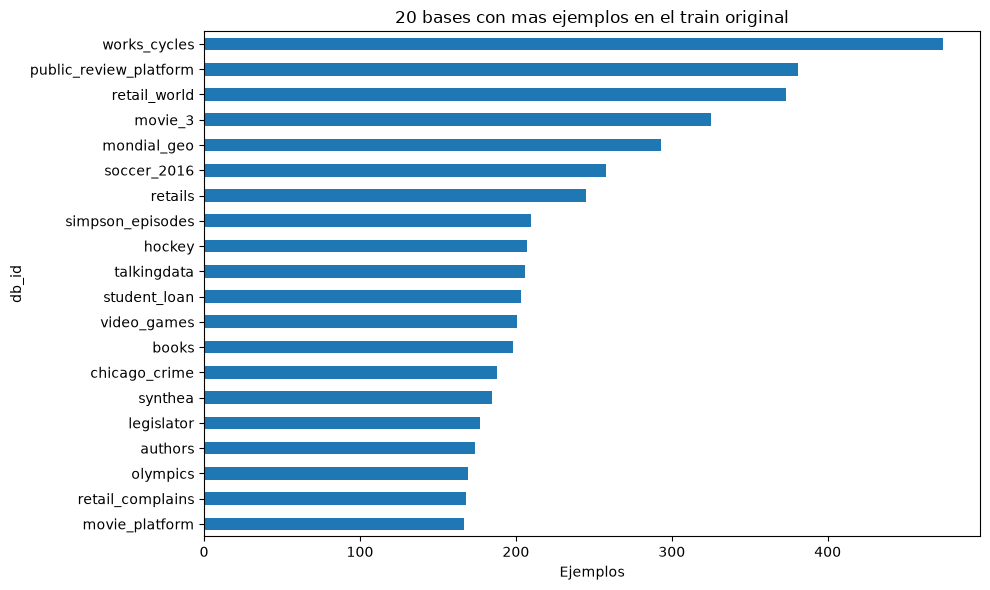

Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\03_construcciones_sql_bird.png


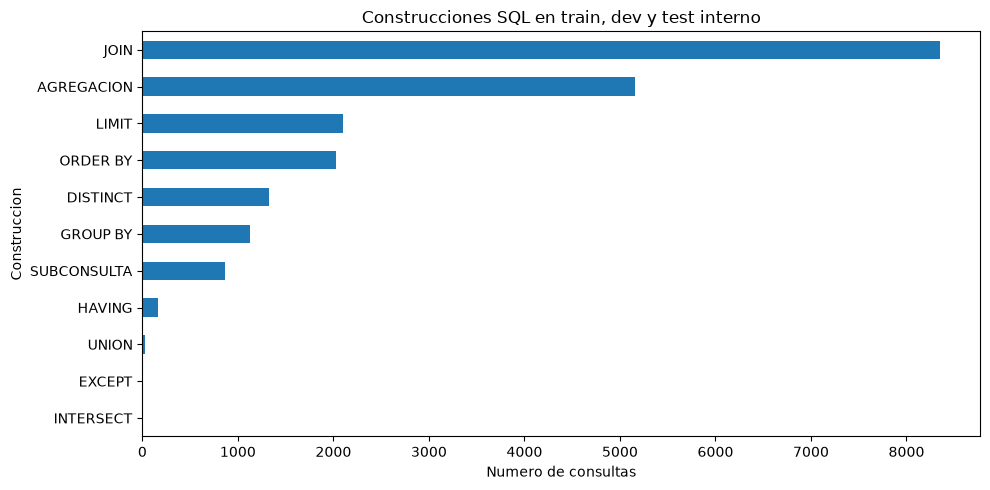

In [90]:
DATA_DIR=Path("Proyecto/Datos")
if not DATA_DIR.is_dir(): DATA_DIR=Path(".")
GRAPH_DIR=DATA_DIR/"graficas_bird_completo_esquemas"
GRAPH_DIR.mkdir(parents=True,exist_ok=True)
def save_figure(filename):
    name = str(filename).removesuffix(".png")
    while name.endswith("_bird"):
        name = name[:-len("_bird")]
    path = GRAPH_DIR / f"{name}_bird.png"
    plt.savefig(path,dpi=300,bbox_inches="tight")
    print(f"Grafica guardada: {path.resolve()}")

counts=df["split"].value_counts().reindex(["train","validation","test_interno"])
plt.figure(figsize=(7,4)); counts.plot(kind="bar")
plt.title("Ejemplos por particion experimental"); plt.xlabel(""); plt.ylabel("Ejemplos"); plt.xticks(rotation=0); plt.tight_layout()
save_figure("01_particiones"); plt.show()

top_db=train_full["db_id"].value_counts().head(20)
plt.figure(figsize=(10,6)); top_db.sort_values().plot(kind="barh")
plt.title("20 bases con mas ejemplos en el train original"); plt.xlabel("Ejemplos"); plt.ylabel("db_id"); plt.tight_layout()
save_figure("02_top_bases"); plt.show()

plt.figure(figsize=(10,5)); construct_counts.sort_values().plot(kind="barh")
plt.title("Construcciones SQL en train, dev y test interno"); plt.xlabel("Numero de consultas"); plt.ylabel("Construccion"); plt.tight_layout()
save_figure("03_construcciones_sql"); plt.show()


### 7.1. Distribución por base en el conjunto completo

Como en Spider, se muestran las bases con más ejemplos considerando todas las particiones públicas cargadas. El gráfico anterior de train original se conserva como referencia de esa fuente.


,ejemplos
db_id,
works_cycles,474
public_review_platform,381
retail_world,373
movie_3,325
mondial_geo,293
soccer_2016,258
retails,245
simpson_episodes,210
hockey,207


Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\13_top_bases_todas_particiones_bird.png


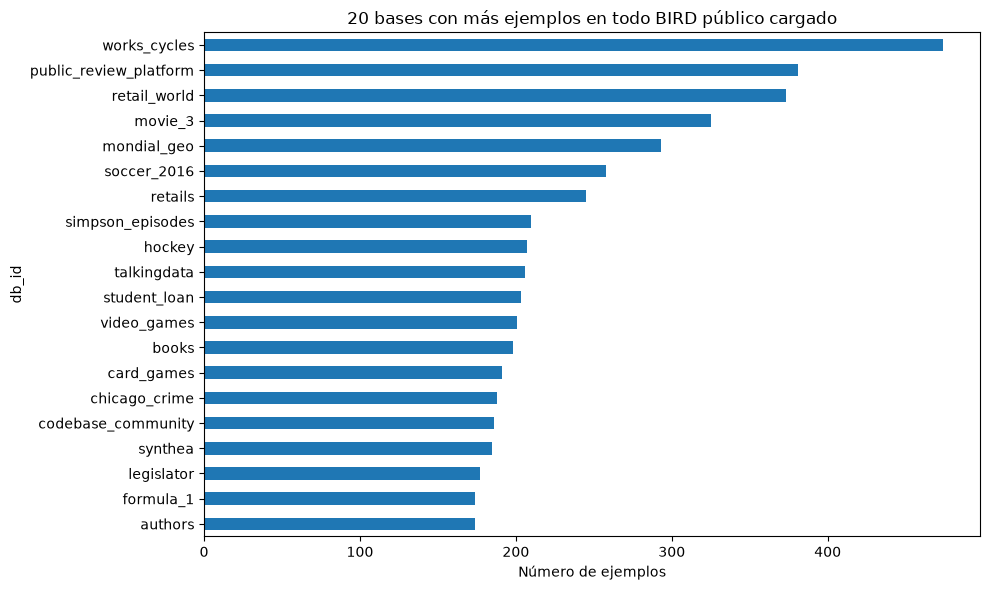

In [91]:
top_db_all = df["db_id"].value_counts().head(20)
display(top_db_all.to_frame("ejemplos"))
plt.figure(figsize=(10, 6))
top_db_all.sort_values().plot(kind="barh")
plt.title("20 bases con más ejemplos en todo BIRD público cargado")
plt.xlabel("Número de ejemplos")
plt.ylabel("db_id")
plt.tight_layout()
save_figure("13_top_bases_todas_particiones")
plt.show()


## 8. Graficas: longitudes y evidencia

Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\04_longitud_preguntas_bird.png


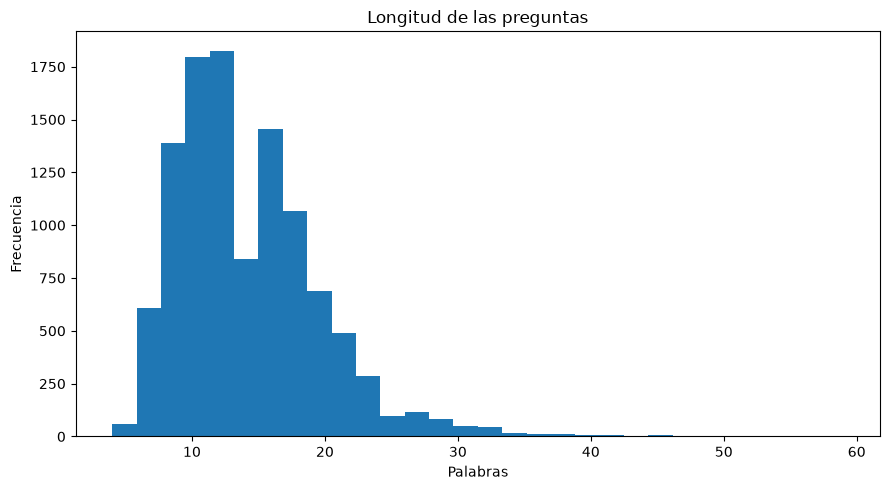

Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\05_longitud_sql_bird.png


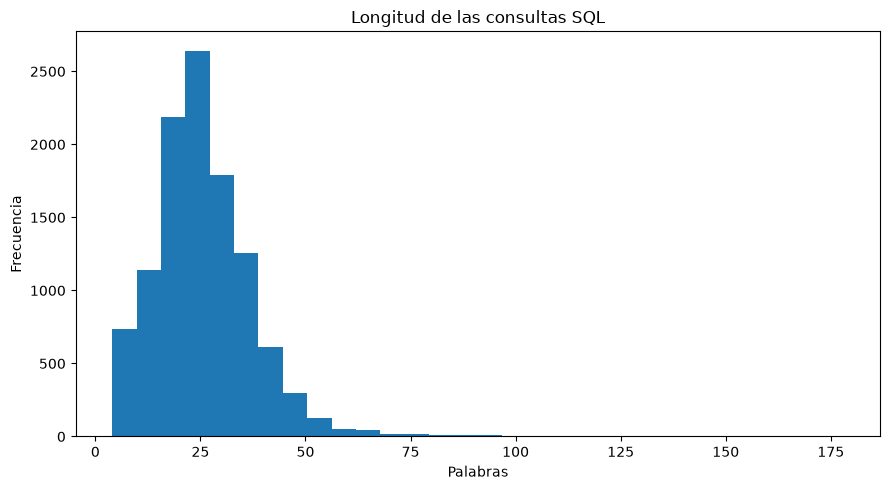

Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\06_longitud_evidence_bird.png


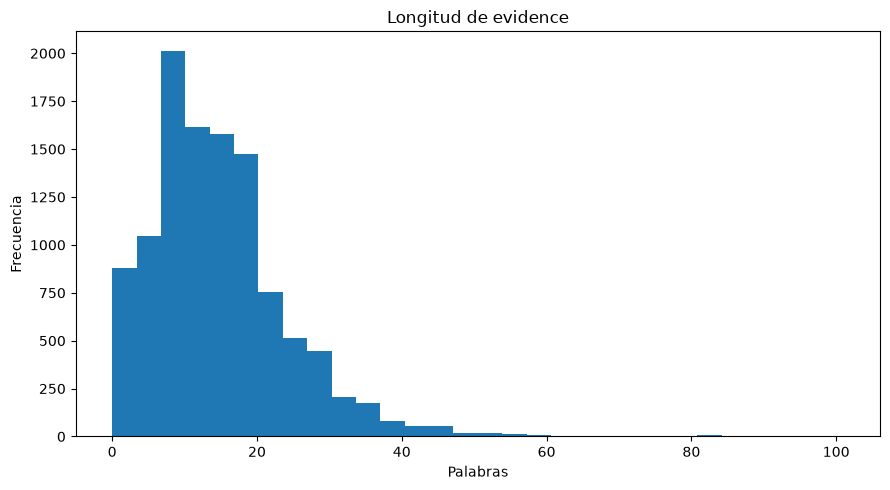

Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\07_evidence_presencia_bird.png


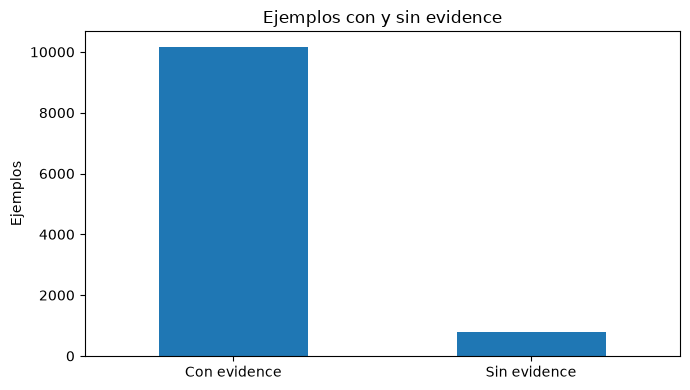

Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\08_pregunta_vs_sql_bird.png


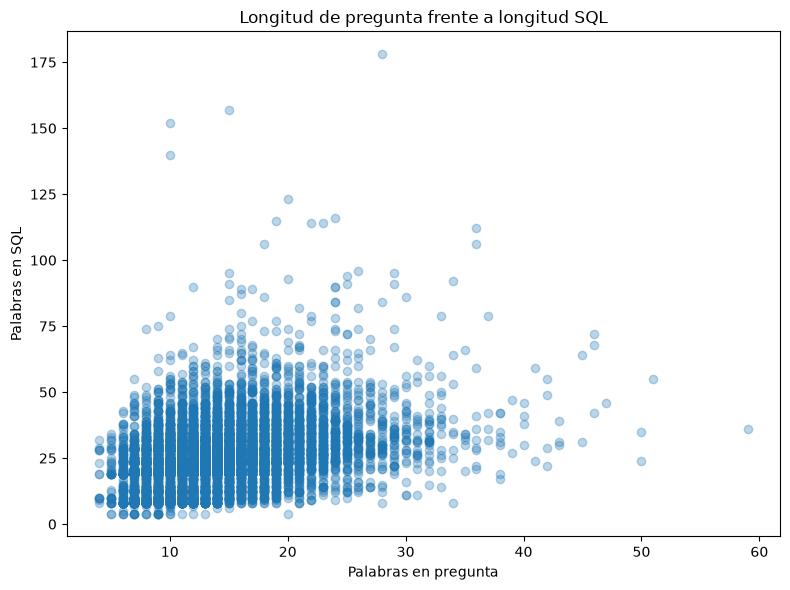

Correlacion pregunta-SQL: 0.374
Ejemplos con evidence no vacia: 10169 / 10962


In [92]:
for column,title,xlabel,filename in [
    ("question_words","Longitud de las preguntas","Palabras","04_longitud_preguntas"),
    ("sql_words","Longitud de las consultas SQL","Palabras","05_longitud_sql"),
    ("evidence_words","Longitud de evidence","Palabras","06_longitud_evidence")
]:
    plt.figure(figsize=(9,5)); plt.hist(df[column],bins=30)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("Frecuencia"); plt.tight_layout()
    save_figure(filename); plt.show()

has_evidence=df["evidence"].fillna("").str.strip().ne("")
evidence_counts=has_evidence.value_counts().reindex([True,False],fill_value=0)
evidence_counts.index=["Con evidence","Sin evidence"]
plt.figure(figsize=(7,4)); evidence_counts.plot(kind="bar")
plt.title("Ejemplos con y sin evidence"); plt.xlabel(""); plt.ylabel("Ejemplos"); plt.xticks(rotation=0); plt.tight_layout()
save_figure("07_evidence_presencia"); plt.show()

plt.figure(figsize=(8,6)); plt.scatter(df["question_words"],df["sql_words"],alpha=.3)
plt.title("Longitud de pregunta frente a longitud SQL"); plt.xlabel("Palabras en pregunta"); plt.ylabel("Palabras en SQL"); plt.tight_layout()
save_figure("08_pregunta_vs_sql"); plt.show()
print("Correlacion pregunta-SQL:",round(df[["question_words","sql_words"]].corr().iloc[0,1],3))
print("Ejemplos con evidence no vacia:",int(has_evidence.sum()),"/",len(df))


## 9. Análisis de esquemas y vocabulario

### 9.1. Tamaño de los esquemas

Los conteos se calculan por base de datos, sin repetir el esquema por cada pregunta.


Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\09_tamano_esquemas_bird.png


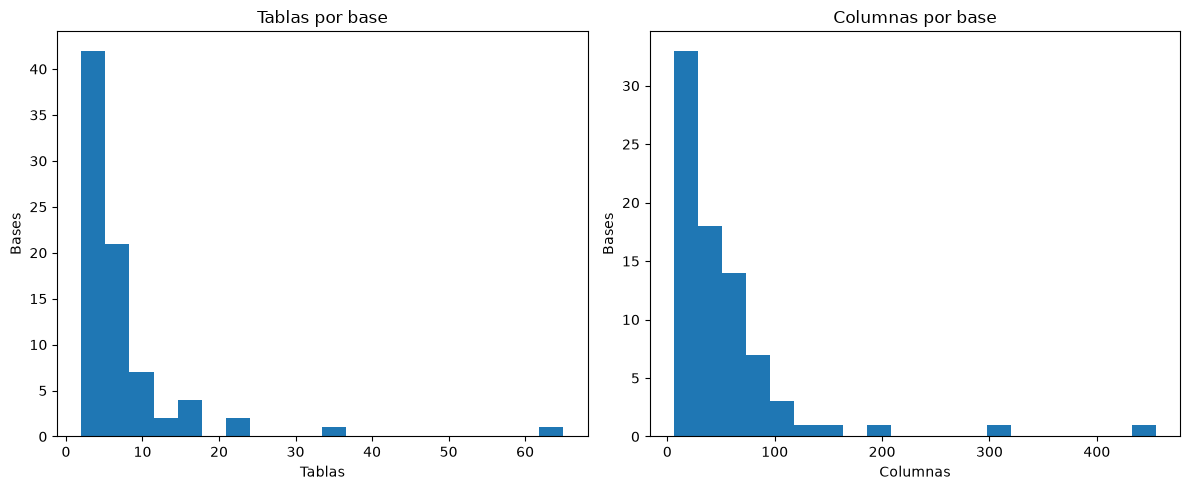

In [93]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].hist(schema_summary["num_tables"],bins=20); axes[0].set_title("Tablas por base"); axes[0].set_xlabel("Tablas"); axes[0].set_ylabel("Bases")
axes[1].hist(schema_summary["num_columns"],bins=20); axes[1].set_title("Columnas por base"); axes[1].set_xlabel("Columnas"); axes[1].set_ylabel("Bases")
fig.tight_layout(); save_figure("09_tamano_esquemas"); plt.show()



### 9.2. Tipos de columna

Cada columna real se cuenta una vez por base. La figura resume los tipos declarados en los metadatos.


,numero_de_columnas
text,2096
integer,1633
real,377
datetime,137
date,88
blob,6


Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\10_tipos_columnas_bird.png


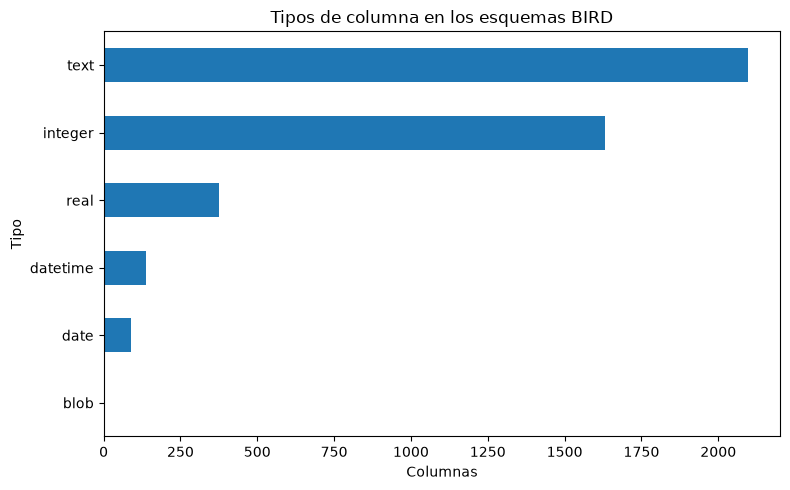

In [94]:
type_counts=Counter()
for counts_by_type in schema_summary["column_type_counts"]: type_counts.update(counts_by_type)
type_freq=pd.Series(type_counts).sort_values(ascending=False)
display(type_freq.to_frame("numero_de_columnas"))
plt.figure(figsize=(8,5)); type_freq.sort_values().plot(kind="barh")
plt.title("Tipos de columna en los esquemas BIRD"); plt.xlabel("Columnas"); plt.ylabel("Tipo"); plt.tight_layout()
save_figure("10_tipos_columnas"); plt.show()



### 9.3. Relaciones y claves dentro de los esquemas

Este análisis corresponde al de Spider, aplicado a los esquemas de BIRD. Cada base aporta **una sola observación**, independientemente de cuántas preguntas tenga.

- `num_primary_keys`: número de columnas distintas que forman claves primarias. Las columnas de una clave compuesta se cuentan individualmente; esta métrica no cuenta restricciones PK.
- `num_foreign_keys`: número de relaciones de clave foránea declaradas. Puede haber varias entre las mismas dos tablas.
- `tables_with_foreign_keys` y `pct_tables_with_foreign_keys`: tablas que participan como origen o destino de alguna FK, y su porcentaje respecto de todas las tablas de la base.
- `key_columns` y `pct_columns_marked_as_keys`: columnas distintas que son PK o participan en una FK como origen o destino, y su porcentaje respecto de todas las columnas de la base.

Una columna que cumple varios papeles se cuenta una sola vez en `key_columns`. Participar como destino de una FK no convierte a esa columna en FK de origen. El comodín `*` se excluye. Estos indicadores describen metadatos, no el número de registros ni el espacio que ocupa la base.


,num_tables,num_columns,num_primary_keys,num_foreign_keys,tables_with_foreign_keys,pct_tables_with_foreign_keys,key_columns,pct_columns_marked_as_keys
count,80.00,80.00,80.00,80.00,80.00,80.00,80.00,80.00
mean,7.46,54.21,9.02,6.58,5.76,80.24,13.41,28.96
std,8.33,64.17,12.59,9.24,6.96,36.96,16.16,17.47
min,2.00,6.00,0.00,0.00,0.00,0.00,1.00,2.94
25%,3.75,20.75,4.00,2.00,3.00,84.62,5.00,17.30
50%,5.00,38.50,6.00,4.00,4.50,100.00,9.00,25.03
75%,8.00,61.75,10.00,8.00,7.25,100.00,16.00,37.50
max,65.00,455.00,91.00,61.00,56.00,100.00,114.00,83.33


Esquema con más columnas: works_cycles (455 columnas en 65 tablas)
Esquema con más relaciones FK: works_cycles (61 relaciones)
Diez esquemas con mayor número de relaciones FK:


,db_id,num_tables,num_columns,num_primary_keys,num_foreign_keys,tables_with_foreign_keys,pct_tables_with_foreign_keys,key_columns,pct_columns_marked_as_keys
77,works_cycles,65,455,91,61,56,86.15,114,25.05
32,hockey,22,300,30,42,19,86.36,53,17.67
26,european_football_2,7,199,7,29,7,100.00,40,20.10
63,soccer_2016,21,85,35,26,20,95.24,55,64.71
30,formula_1,13,94,17,19,13,100.00,32,34.04
70,synthea,11,85,15,16,10,90.91,25,29.41
69,superstore,6,61,8,16,6,100.00,20,32.79
50,professional_basketball,9,157,16,14,9,100.00,25,15.92
15,codebase_community,8,71,8,13,8,100.00,21,29.58
46,movies_4,17,53,10,13,13,76.47,23,43.40


Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\14_analisis_relacional_esquemas_bird.png


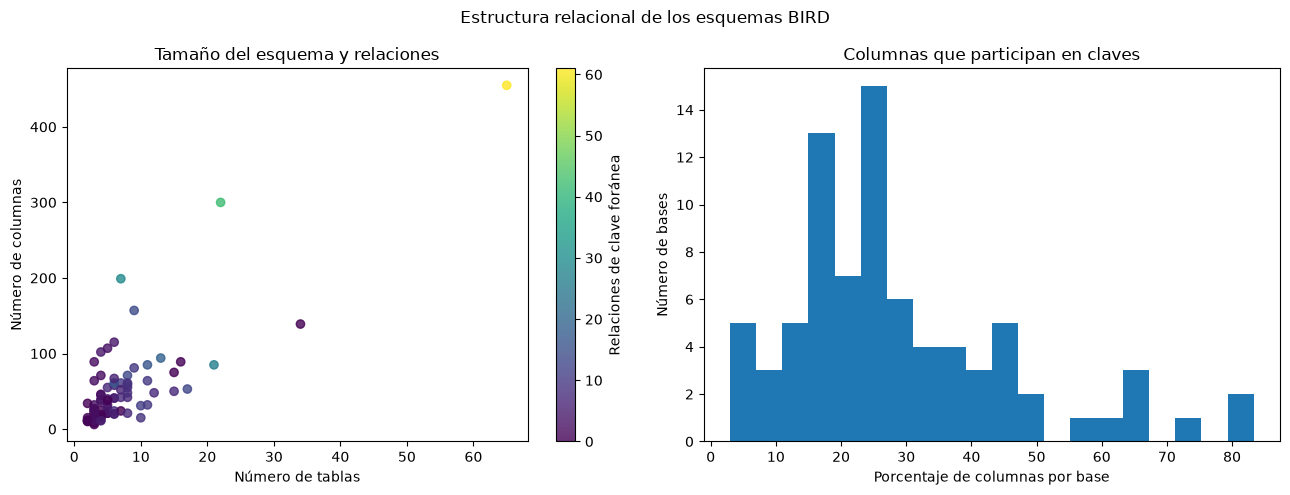

Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\15_distribucion_claves_esquemas_bird.png


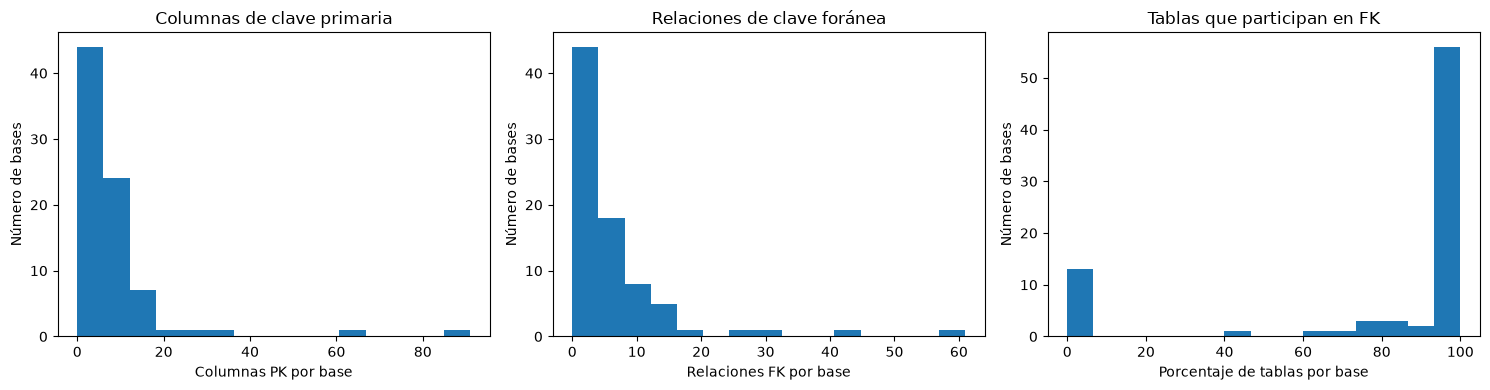

In [95]:
schema_analysis = schema_summary.copy()
display(schema_analysis[schema_metric_columns].describe().round(2))

largest_schema = schema_analysis.loc[schema_analysis["num_columns"].idxmax()]
most_related_schema = schema_analysis.loc[schema_analysis["num_foreign_keys"].idxmax()]
print(
    f"Esquema con más columnas: {largest_schema['db_id']} "
    f"({int(largest_schema['num_columns'])} columnas en {int(largest_schema['num_tables'])} tablas)"
)
print(
    f"Esquema con más relaciones FK: {most_related_schema['db_id']} "
    f"({int(most_related_schema['num_foreign_keys'])} relaciones)"
)
print("Diez esquemas con mayor número de relaciones FK:")
display(
    schema_analysis.sort_values(
        ["num_foreign_keys", "num_columns", "db_id"], ascending=[False, False, True]
    )[["db_id"] + schema_metric_columns].head(10).round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
points = axes[0].scatter(
    schema_analysis["num_tables"], schema_analysis["num_columns"],
    c=schema_analysis["num_foreign_keys"], cmap="viridis", alpha=0.8,
)
axes[0].set_title("Tamaño del esquema y relaciones")
axes[0].set_xlabel("Número de tablas")
axes[0].set_ylabel("Número de columnas")
fig.colorbar(points, ax=axes[0], label="Relaciones de clave foránea")
axes[1].hist(schema_analysis["pct_columns_marked_as_keys"], bins=20)
axes[1].set_title("Columnas que participan en claves")
axes[1].set_xlabel("Porcentaje de columnas por base")
axes[1].set_ylabel("Número de bases")
fig.suptitle("Estructura relacional de los esquemas BIRD")
fig.tight_layout()
save_figure("14_analisis_relacional_esquemas")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature, title, xlabel in zip(
    axes,
    ["num_primary_keys", "num_foreign_keys", "pct_tables_with_foreign_keys"],
    ["Columnas de clave primaria", "Relaciones de clave foránea", "Tablas que participan en FK"],
    ["Columnas PK por base", "Relaciones FK por base", "Porcentaje de tablas por base"],
):
    ax.hist(schema_analysis[feature], bins=15)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Número de bases")
fig.tight_layout()
save_figure("15_distribucion_claves_esquemas")
plt.show()


In [96]:
from IPython.display import Markdown, display

no_fk = int(schema_analysis["num_foreign_keys"].eq(0).sum())
dominant_type = type_freq.idxmax()
dominant_type_pct = 100 * type_freq.max() / type_freq.sum()
display(Markdown(
    f"**Resultados calculados sobre los esquemas de BIRD.** Se analizan "
    f"**{len(schema_analysis)} bases distintas**, con una mediana de "
    f"**{schema_analysis['num_tables'].median():.1f} tablas** y "
    f"**{schema_analysis['num_columns'].median():.1f} columnas** por base. "
    f"El número de columnas varía entre {int(schema_analysis['num_columns'].min())} "
    f"y {int(schema_analysis['num_columns'].max())}. "
    f"El tipo más frecuente es `{dominant_type}`, con el "
    f"{dominant_type_pct:.1f} % de las columnas con tipo contabilizado.\n\n"
    f"La mediana de relaciones FK por base es "
    f"**{schema_analysis['num_foreign_keys'].median():.1f}**. "
    f"En {no_fk} bases no hay relaciones FK declaradas. "
    f"La mediana del porcentaje de tablas que participan en alguna FK es "
    f"**{schema_analysis['pct_tables_with_foreign_keys'].median():.1f} %**, y la "
    f"mediana del porcentaje de columnas que son PK o participan en FK es "
    f"**{schema_analysis['pct_columns_marked_as_keys'].median():.1f} %**. "
    f"Estas dos últimas cifras son medianas de porcentajes por base."
))


**Resultados calculados sobre los esquemas de BIRD.** Se analizan **80 bases distintas**, con una mediana de **5.0 tablas** y **38.5 columnas** por base. El número de columnas varía entre 6 y 455. El tipo más frecuente es `text`, con el 48.3 % de las columnas con tipo contabilizado.

La mediana de relaciones FK por base es **4.0**. En 13 bases no hay relaciones FK declaradas. La mediana del porcentaje de tablas que participan en alguna FK es **100.0 %**, y la mediana del porcentaje de columnas que son PK o participan en FK es **25.0 %**. Estas dos últimas cifras son medianas de porcentajes por base.

**Interpretación de las gráficas de esquemas.** Los histogramas de tablas y columnas muestran la variación de tamaño entre bases. En la dispersión, cada punto representa una base: su posición describe el tamaño y su color indica las relaciones FK declaradas. El histograma de tipos describe la composición de las columnas, contabilizando cada esquema una sola vez.

Una mayor cantidad de tablas y columnas puede ampliar las opciones que debe considerar el modelo para asociar la pregunta con el esquema (*schema linking*). Las PK y FK aportan información sobre identificación de registros y relaciones que pueden orientar un `JOIN`. Sin embargo, estas métricas no miden por sí solas la dificultad de cada pregunta ni cuántas tablas usa su SQL.

La proporción de tablas que participan en FK no indica que todas estén conectadas entre sí: pueden existir grupos separados. La ausencia de FK declaradas tampoco demuestra que sea imposible relacionar tablas mediante una consulta. Las conclusiones se limitan a los metadatos disponibles en los archivos de BIRD.


### 9.4. Comparación de esquemas entre particiones

La tabla siguiente compara bases, tamaños y relaciones en `train`, `validation` y `test_interno`. Los cálculos usan una fila por base para evitar que las bases con más preguntas pesen más en la comparación. La matriz muestra las intersecciones de `db_id`; fuera de la diagonal se esperan ceros, conforme a la separación aplicada al principio.

Las cajas muestran la mediana, los cuartiles y la dispersión de columnas y relaciones FK por base. Permiten observar diferencias estructurales entre particiones. Evaluar en bases ausentes del entrenamiento permite estudiar generalización a esquemas nuevos, pero estas gráficas no miden el desempeño de un modelo. `test_interno` sigue siendo una reserva experimental del entrenamiento original; no es el test oficial oculto.


,bases,tablas_totales,columnas_totales,mediana_tablas,mediana_columnas,mediana_columnas_PK,mediana_relaciones_FK,mediana_pct_tablas_con_FK
split,,,,,,,,
train,55,441,3043,5.0,37.0,6.0,4.0,100.0
validation,11,75,798,7.0,64.0,7.0,8.0,100.0
test_interno,14,81,496,4.5,24.0,4.0,3.5,100.0


Bases compartidas: diagonal = bases de cada partición; fuera de diagonal = intersecciones.


,train,validation,test_interno
train,55,0,0
validation,0,11,0
test_interno,0,0,14


Bases de train: address, airline, app_store, authors, bike_share_1, book_publishing_company, car_retails, cars, chicago_crime, citeseer, codebase_comments, coinmarketcap, college_completion, computer_student, cookbook, disney, donor, european_football_1, food_inspection, food_inspection_2, hockey, ice_hockey_draft, image_and_language, language_corpus, law_episode, legislator, menu, mondial_geo, movie, movie_3, movielens, movies_4, music_tracker, olympics, professional_basketball, public_review_platform, regional_sales, restaurant, retail_complains, retail_world, retails, sales, sales_in_weather, shakespeare, shipping, simpson_episodes, soccer_2016, social_media, software_company, student_loan, superstore, university, video_games, works_cycles, world
Bases de validation: california_schools, card_games, codebase_community, debit_card_specializing, european_football_2, financial, formula_1, student_club, superhero, thrombosis_prediction, toxicology
Bases de test_interno: beer_factory, boo

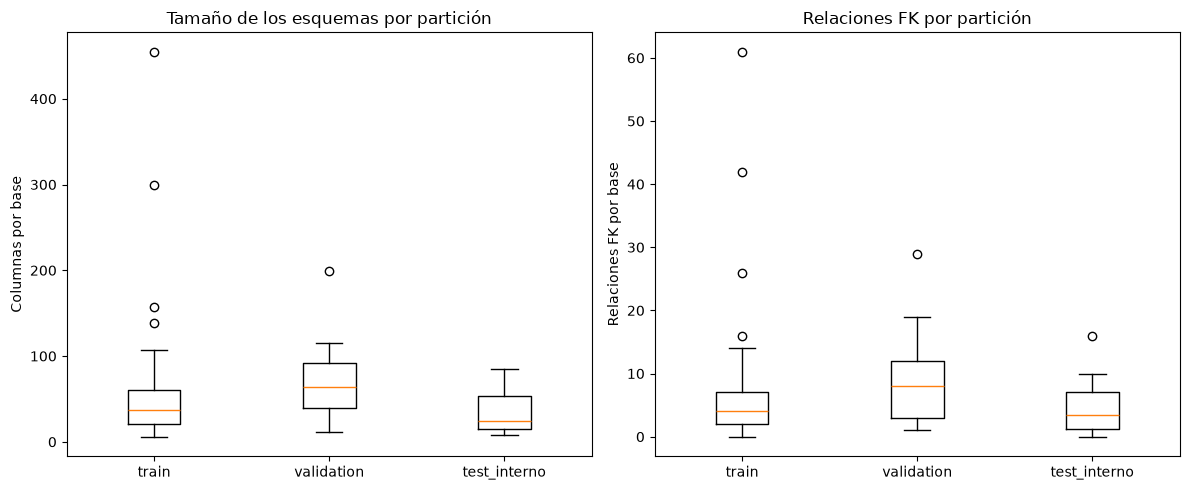

In [97]:
split_order = ["train", "validation", "test_interno"]
db_membership = df[["db_id", "split"]].drop_duplicates()
if db_membership["db_id"].duplicated().any():
    raise ValueError("Una base aparece en más de una partición experimental.")

schema_by_split = schema_analysis.merge(
    db_membership, on="db_id", how="left", validate="one_to_one"
)
schema_split_summary = schema_by_split.groupby("split").agg(
    bases=("db_id", "size"),
    tablas_totales=("num_tables", "sum"),
    columnas_totales=("num_columns", "sum"),
    mediana_tablas=("num_tables", "median"),
    mediana_columnas=("num_columns", "median"),
    mediana_columnas_PK=("num_primary_keys", "median"),
    mediana_relaciones_FK=("num_foreign_keys", "median"),
    mediana_pct_tablas_con_FK=("pct_tables_with_foreign_keys", "median"),
).reindex(split_order)
display(schema_split_summary.round(2))

bases_por_particion = {
    split: set(db_membership.loc[db_membership["split"].eq(split), "db_id"])
    for split in split_order
}
overlap = pd.DataFrame(
    [[len(bases_por_particion[a] & bases_por_particion[b]) for b in split_order]
     for a in split_order],
    index=split_order, columns=split_order,
)
print("Bases compartidas: diagonal = bases de cada partición; fuera de diagonal = intersecciones.")
display(overlap)
for split in split_order:
    print(f"Bases de {split}: {', '.join(sorted(bases_por_particion[split]))}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, feature, title, ylabel in zip(
    axes, ["num_columns", "num_foreign_keys"],
    ["Tamaño de los esquemas por partición", "Relaciones FK por partición"],
    ["Columnas por base", "Relaciones FK por base"],
):
    values = [
        schema_by_split.loc[schema_by_split["split"].eq(split), feature].to_numpy()
        for split in split_order
    ]
    ax.boxplot(values)
    ax.set_xticks(range(1, len(split_order) + 1))
    ax.set_xticklabels(split_order)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
fig.tight_layout()
save_figure("16_comparacion_esquemas_particiones")
plt.show()


### 9.5. Vocabulario de las preguntas


Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\11_nube_palabras_bird.png


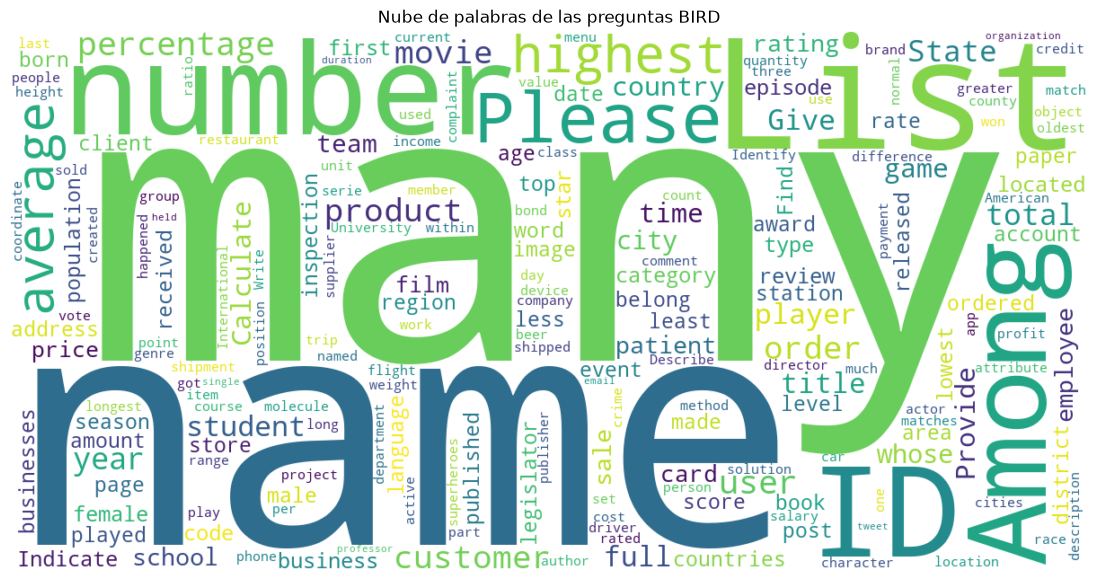

,palabra,frecuencia
0,list,1878
1,name,1522
2,number,1133
3,among,886
4,most,780
5,please,751
6,highest,715
7,average,713
8,percentage,634
9,names,539


Grafica guardada: C:\Users\adwar\Documents\repositorios\Learning\NLP-ml\Proyecto\Datos\graficas_bird_completo_esquemas\12_frecuencia_palabras_bird.png


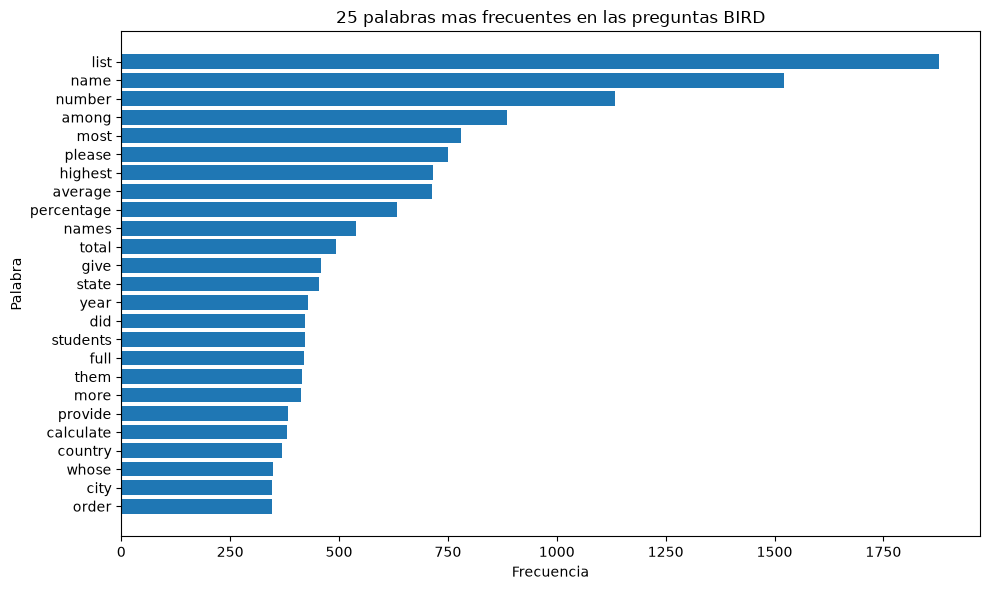

In [98]:
text_questions=" ".join(df["question"].dropna().astype(str))
wc=WordCloud(width=1200,height=600,background_color="white",collocations=False).generate(text_questions)
plt.figure(figsize=(14,7)); plt.imshow(wc,interpolation="bilinear"); plt.axis("off"); plt.title("Nube de palabras de las preguntas BIRD")
save_figure("11_nube_palabras"); plt.show()


stopwords={
    "the","a","an","of","in","on","to","and","is","are","was","were",
    "what","which","who","how","many","for","with","from","that","have",
    "has","do","does","all","their","than","by","be","as","there"
}
tokens=re.findall(r"[A-Za-z]+",text_questions.lower())
tokens=[token for token in tokens if token not in stopwords and len(token)>2]
word_freq_df=pd.DataFrame(Counter(tokens).most_common(25),columns=["palabra","frecuencia"])
display(word_freq_df)
plt.figure(figsize=(10,6)); plt.barh(word_freq_df["palabra"][::-1],word_freq_df["frecuencia"][::-1])
plt.title("25 palabras mas frecuentes en las preguntas BIRD"); plt.xlabel("Frecuencia"); plt.ylabel("Palabra"); plt.tight_layout()
save_figure("12_frecuencia_palabras"); plt.show()


## Análisis e interpretacion de las gráficas

Las tablas de resumen reportan los tamanos efectivos de cada partición después de reservar bases de train completas para `test_interno`. La suma de train y test interno debe coincidir con los 9.428 ejemplos del train original; validation corresponde al dev público.

- **Particiones:** el grafico confirma visualmente que los registros se distribuyen entre entrenamiento, validación oficial y prueba interna. La prueba interna se separa por `db_id`, por lo que el modelo no ve esos esquemas durante el entrenamiento.
- **Bases y consultas:** la frecuencia por base permite reconocer desequilibrios entre dominios. El conteo de construcciones muestra la variedad de SQL (por ejemplo, joins, agregaciones, agrupamientos y subconsultas); las categorias pueden aparecer simultaneamente en una consulta.
- **Preguntas, SQL y evidence:** los histogramas describen la longitud y variabilidad de los textos. La grafica de presencia de `evidence` cuantifica cuantos registros tienen o no contexto auxiliar. La correlación entre longitud de pregunta y SQL es una medida descriptiva y no debe interpretarse como dificultad causal. El histograma de `evidence` caracteriza el conocimiento auxiliar disponible.
- **Esquemas:** las distribuciones de tablas y columnas describen la complejidad estructural de las bases; la frecuencia de tipos resume la composición de las columnas. Estas variables enriquecen el análisis de cada par pregunta-SQL.
- **Vocabulario:** la nube y las 25 palabras mas frecuentes permiten identificar terminos recurrentes de manera exploratoria, sin inferir por si solas la intencion de cada consulta.

El test interno ofrece una estimacion basada en esquemas de train no vistos, mientras que el dev oficial conserva el papel de validación. Ninguno sustituye al test oculto oficial de BIRD.


## 10. Ejemplos detallados de pregunta, evidencia, SQL y esquema

Se muestra una base principal y cinco bases adicionales distintas. Cada ejemplo incluye su identificador `db_id`, partición, procedencia, pregunta, evidencia auxiliar (`evidence`) y SQL de referencia. Después se presenta **el esquema completo de esa base**, sin límites de tablas ni columnas.

Cada tabla aparece por separado con los nombres originales de sus columnas, tipos y claves. **PK** identifica las columnas que forman la clave primaria; si es compuesta, sus columnas funcionan conjuntamente. **FK** identifica la columna de origen de una clave foránea, y la columna «Referencia de la FK» indica la tabla y columna a la que apunta. Una columna referenciada no se marca como FK por ese solo motivo. Al final de cada esquema se enumeran todas las relaciones declaradas.

El número de columnas es la suma de las columnas de todas las tablas, excluyendo el comodín `*`. Por ejemplo, «7 tablas y 27 columnas» significa 27 columnas en total. Una columna llamada `id` en dos tablas se cuenta en ambas. La información presentada describe los metadatos del esquema; no son los registros almacenados en las tablas.


In [99]:
from html import escape
from IPython.display import HTML, Markdown, display


def mostrar_esquema_completo(db_id):
    schema = schemas[db_id]
    tables = schema.get("table_names_original")
    if tables is None:
        tables = schema["table_names"]
    columns = schema.get("column_names_original")
    if columns is None:
        columns = schema["column_names"]
    types = schema["column_types"]
    pk_indices = indices_clave_primaria(schema.get("primary_keys", []))

    # Una FK se marca en la columna de origen; el destino se muestra como referencia.
    references = {}
    relations = []
    for source_idx, target_idx in schema.get("foreign_keys", []):
        source_idx, target_idx = int(source_idx), int(target_idx)
        source_table, source_column = columns[source_idx]
        target_table, target_column = columns[target_idx]
        references.setdefault(source_idx, []).append(
            f"{tables[target_table]}.{target_column}"
        )
        relations.append({
            "Tabla de origen": tables[source_table],
            "Columna FK": source_column,
            "Tabla referenciada": tables[target_table],
            "Columna referenciada": target_column,
        })

    total_columns = sum(
        1 for table_id, name in columns if table_id >= 0 and name != "*"
    )
    display(Markdown(
        f"**Esquema completo:** {len(tables)} tablas y {total_columns} columnas "
        f"en total; {len(relations)} relaciones de clave foránea."
    ))

    # to_html muestra todas las filas y evita el recorte habitual de los DataFrames.
    for table_id, table_name in enumerate(tables):
        rows = []
        for column_idx, (owner_id, column_name) in enumerate(columns):
            if owner_id != table_id or column_name == "*":
                continue
            markers = []
            if column_idx in pk_indices:
                markers.append("PK")
            if column_idx in references:
                markers.append("FK")
            rows.append({
                "Columna": column_name,
                "Tipo": types[column_idx] if column_idx < len(types) else "No indicado",
                "Clave": ", ".join(markers) or "—",
                "Referencia de la FK": "; ".join(references.get(column_idx, [])) or "—",
            })
        display(HTML(
            f"<h4>Tabla: {escape(str(table_name))} ({len(rows)} columnas)</h4>"
        ))
        if rows:
            display(HTML(pd.DataFrame(rows).to_html(
                index=False, escape=True, max_rows=None, max_cols=None
            )))
        else:
            display(Markdown("No hay columnas declaradas para esta tabla."))

    display(Markdown("**Todas las relaciones de clave foránea:**"))
    if relations:
        display(HTML(pd.DataFrame(relations).to_html(
            index=False, escape=True, max_rows=None, max_cols=None
        )))
    else:
        display(Markdown("El archivo de esquema no declara relaciones de clave foránea."))


def mostrar_ejemplo_con_esquema(example, titulo):
    db_id = example["db_id"]
    evidence = example.get("evidence")
    if pd.isna(evidence) or not str(evidence).strip():
        evidence = "Sin evidencia anotada."
    display(HTML(f"<h3>{escape(titulo)}: {escape(str(db_id))}</h3>"))
    display(Markdown(
        f"**Base (db_id):** `{db_id}`  |  "
        f"**Partición:** {example['split']}  |  "
        f"**Procedencia:** {example['source_split']}\n\n"
        f"**Pregunta:** {example['question']}\n\n"
        f"**Evidencia auxiliar (evidence):** {evidence}\n\n"
        f"**SQL de referencia:**\n\n```sql\n{example['SQL']}\n```"
    ))
    mostrar_esquema_completo(db_id)


# Una base principal y hasta cinco bases adicionales distintas, sin recortar esquemas.
ejemplo_principal = df.sample(1, random_state=42).iloc[0]
mostrar_ejemplo_con_esquema(ejemplo_principal, "Ejemplo principal")

# Mezclar antes de quitar duplicados permite elegir un ejemplo reproducible por base.
otras_bases = (
    df.loc[df["db_id"] != ejemplo_principal["db_id"]]
    .sample(frac=1, random_state=42)
    .drop_duplicates("db_id")
    .head(5)
)
for _, ejemplo in otras_bases.iterrows():
    mostrar_ejemplo_con_esquema(ejemplo, "Ejemplo de otra base de datos")


**Base (db_id):** `coinmarketcap`  |  **Partición:** train  |  **Procedencia:** train_original

**Pregunta:** What is the name of the coin with the highest price?

**Evidencia auxiliar (evidence):** the highest price refers to max(price)

**SQL de referencia:**

```sql
SELECT T1.name FROM coins AS T1 INNER JOIN historical AS T2 ON T1.id = T2.coin_id WHERE T2.price = ( SELECT MAX(price) FROM historical )
```

**Esquema completo:** 2 tablas y 34 columnas en total; 0 relaciones de clave foránea.

Columna,Tipo,Clave,Referencia de la FK
id,integer,PK,—
name,text,—,—
slug,text,—,—
symbol,text,—,—
status,text,—,—
category,text,—,—
description,text,—,—
subreddit,text,—,—
notice,text,—,—
tags,text,—,—


Columna,Tipo,Clave,Referencia de la FK
date,date,—,—
coin_id,integer,—,—
cmc_rank,integer,—,—
market_cap,real,—,—
price,real,—,—
open,real,—,—
high,real,—,—
low,real,—,—
close,real,—,—
time_high,text,—,—


**Todas las relaciones de clave foránea:**

...

Columna,Tipo,Clave,Referencia de la FK
Name,text,PK,—
River,text,—,—
Lake,text,—,—
Sea,text,—,—
Length,real,—,—
SourceLongitude,real,—,—
SourceLatitude,real,—,—
Mountains,text,—,—
SourceAltitude,real,—,—
EstuaryLongitude,real,—,—


Columna,Tipo,Clave,Referencia de la FK
Name,text,PK,—
Depth,real,—,—


Columna,Tipo,Clave,Referencia de la FK
Country,text,PK,—
Target,text,—,—


**Todas las relaciones de clave foránea:**

El archivo de esquema no declara relaciones de clave foránea.

## 11. Justificacion de BIRD para el proyecto

BIRD es pertinente para Text-to-SQL porque combina preguntas en lenguaje natural, consultas de referencia, evidencia auxiliar y bases de datos de dominios diversos. El acceso a los archivos de esquema permite condicionar la generación al conjunto correcto de tablas, columnas, tipos y relaciones.

La partición interna por bases completas evita la filtración de esquemas entre entrenamiento y test interno. El dev oficial puede utilizarse para validar decisiones de modelado; los resultados del test interno deben reportarse como resultados experimentales propios y distinguirse de la evaluación oficial, cuyo test esta oculto.


## Referencias

- Li, J. et al. (2024). *Can LLM Already Serve as a Database Interface? A Big Bench for Large-Scale Database Grounded Text-to-SQLs*. NeurIPS.
- [BIRD: pagina oficial, descargas y benchmark](https://bird-bench.github.io/).
- [Archivos de anotaciones y esquemas: Hugging Face, Deema/BIRD-SQL](https://huggingface.co/datasets/Deema/BIRD-SQL).
- [BIRD-SQL train filtrado, referencia de los 6.601 ejemplos frente a los 9.428 originales](https://huggingface.co/datasets/birdsql/bird23-train-filtered).
